# Test Notebook - Example

In [1]:
import numpy as np
import numpy.random as npr
import random
from IPython.display import display, Audio
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

# Importing Trained Models (and Any Preprocessing Functions)

Start by loading the final trained model **and any preprocessing functions** that you might have used.

In [2]:
class CNN_LSTM_EmotionClassifier(nn.Module):
    def __init__(self, num_classes=5, lstm_hidden_size=128, lstm_num_layers=2, dropout=0.3):
        super(CNN_LSTM_EmotionClassifier, self).__init__()
        
        # CNN layers for feature extraction (3 layers)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2))
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))
        
        self.dropout_cnn = nn.Dropout(dropout)
        
        # Calculate the size after CNN layers
        # Input: (batch, 1, 128, 282)
        # After 3 pooling layers: (batch, 128, 16, 35)
        self.cnn_output_size = 128 * 16  # channels * height
        
        # LSTM layers for temporal modeling (2 layers, bidirectional)
        self.lstm = nn.LSTM(
            input_size=self.cnn_output_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            dropout=dropout if lstm_num_layers > 1 else 0,
            bidirectional=True  # IMPORTANT: Bidirectional LSTM
        )
        
        # Fully connected layers
        self.dropout_lstm = nn.Dropout(dropout)
        self.fc1 = nn.Linear(lstm_hidden_size * 2, 128)  # *2 for bidirectional
        self.dropout_fc = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # CNN feature extraction
        # Input: (batch, 1, 128, 282)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)  # (batch, 32, 64, 141)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)  # (batch, 64, 32, 70)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)  # (batch, 128, 16, 35)
        
        x = self.dropout_cnn(x)
        
        # Reshape for LSTM: (batch, time_steps, features)
        batch_size, channels, height, width = x.size()
        x = x.permute(0, 3, 1, 2)  # (batch, width, channels, height)
        x = x.reshape(batch_size, width, channels * height)  # (batch, 35, 128*16)
        
        # LSTM temporal modeling
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use last time step output
        x = lstm_out[:, -1, :]
        x = self.dropout_lstm(x)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        
        return x

print("✅ CNN_LSTM_EmotionClassifier model defined")
print("   - Input: (batch, 1, 128, 282) - Mel-spectrogram")
print("   - CNN: 3 conv layers with batch normalization")
print("   - LSTM: 2-layer bidirectional LSTM (hidden_size=128)")
print("   - Output: 5 emotion classes")

✅ CNN_LSTM_EmotionClassifier model defined
   - Input: (batch, 1, 128, 282) - Mel-spectrogram
   - CNN: 3 conv layers with batch normalization
   - LSTM: 2-layer bidirectional LSTM (hidden_size=128)
   - Output: 5 emotion classes


In [3]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

my_model = CNN_LSTM_EmotionClassifier(
    num_classes=5,           # 5 emotion classes
    lstm_hidden_size=128,    # LSTM hidden size
    lstm_num_layers=2,       # 2-layer LSTM
    dropout=0.3              # Dropout rate
).to(device)

# Load trained weights
my_model.load_state_dict(torch.load('best_cnn_lstm_model_v3.pth', map_location=device))
my_model.eval()  

print('✅ Model loaded successfully!')
print(f'   Total parameters: {sum(p.numel() for p in my_model.parameters()):,}')

Using device: cuda
✅ Model loaded successfully!
   Total parameters: 2,752,197


# Load the Test Set Data and Labels

In [4]:
test_data = np.load('Data/test_data_projectC.npy').T  # Transpose to (samples, time)
test_labels = np.load('Data/test_labels_projectC.npy')

print(f"✅ Data loaded successfully!")
print(f"   Audio data shape: {test_data.shape}")
print(f"   Labels shape: {test_labels.shape}")
print(f"   Number of samples: {test_data.shape[0]}")
print(f"   Audio length per sample: {test_data.shape[1]} samples")
print(f"   Number of classes: {len(np.unique(test_labels))}")
print(f"   Class labels: {np.unique(test_labels)}")

✅ Data loaded successfully!
   Audio data shape: (225, 144000)
   Labels shape: (225,)
   Number of samples: 225
   Audio length per sample: 144000 samples
   Number of classes: 5
   Class labels: [1. 2. 3. 4. 5.]


In [5]:
sr = 48000          # Sample rate
N_fft = 1024        # FFT window size
HOP_len = 512       # Hop length
N_melband = 128     # Number of mel bands
f_max = 8000        # Maximum frequency (Hz)

print("Extracting mel-spectrograms...")

melspec = librosa.feature.melspectrogram(
    y=test_data,
    sr=sr,
    n_fft=N_fft,
    hop_length=HOP_len,
    n_mels=N_melband,
    fmax=f_max,
)

melspec_db = librosa.power_to_db(melspec, ref=np.max)

print(f"✅ Mel-spectrogram extraction completed!")
print(f"   Shape: {melspec_db.shape}")
print(f"   Dimensions:")
print(f"   - Samples: {melspec_db.shape[0]}")
print(f"   - Mel bands (frequency): {melspec_db.shape[1]}")
print(f"   - Time frames: {melspec_db.shape[2]}")

Extracting mel-spectrograms...
✅ Mel-spectrogram extraction completed!
   Shape: (225, 128, 282)
   Dimensions:
   - Samples: 225
   - Mel bands (frequency): 128
   - Time frames: 282


In [6]:
test_data_processed = melspec_db[:, np.newaxis, :, :]  
print(f"Original shape: {melspec_db.shape}")
print(f"Reshaped for PyTorch CNN: {test_data_processed.shape}")
print(f"\nDimension interpretation:")
print(f"  Samples: {test_data_processed.shape[0]}")
print(f"  Channels: {test_data_processed.shape[1]} (mono audio)")
print(f"  Frequency bins: {test_data_processed.shape[2]}")
print(f"  Time steps: {test_data_processed.shape[3]}")

Original shape: (225, 128, 282)
Reshaped for PyTorch CNN: (225, 1, 128, 282)

Dimension interpretation:
  Samples: 225
  Channels: 1 (mono audio)
  Frequency bins: 128
  Time steps: 282


# Make predictions

In [7]:

with torch.no_grad():  
    
    test_data_tensor = torch.FloatTensor(test_data_processed).to(device)
    outputs = my_model(test_data_tensor)
    
    test_labels_predictions = torch.argmax(outputs, dim=1).cpu().numpy()
    probabilities = torch.softmax(outputs, dim=1).cpu().numpy()

print(f"   Predictions shape: {test_labels_predictions.shape}")
print(f"   Unique predicted classes: {np.unique(test_labels_predictions)}")
print(f"\n   Prediction distribution:")
unique, counts = np.unique(test_labels_predictions, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"   Class {cls}: {count} samples ({count/len(test_labels_predictions)*100:.1f}%)")

   Predictions shape: (225,)
   Unique predicted classes: [0 1 2 3 4]

   Prediction distribution:
   Class 0: 44 samples (19.6%)
   Class 1: 41 samples (18.2%)
   Class 2: 42 samples (18.7%)
   Class 3: 48 samples (21.3%)
   Class 4: 50 samples (22.2%)


# Evaluate Performance

## For Projects A-D

In [8]:
from sklearn.metrics import f1_score

In [9]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

test_labels_encoded = (test_labels - 1).astype(int)

# Calculate metrics
accuracy = accuracy_score(test_labels_encoded, test_labels_predictions) * 100
f1_weighted = f1_score(test_labels_encoded, test_labels_predictions, average='weighted')


print(f"Accuracy: {accuracy:.2f}%")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print("="*70)

emotion_names = ['1-happy', '2-sad', '3-angry', '4-surprised', '5-neutral']
print("\nDetailed Classification Report:")
print(classification_report(
    test_labels_encoded, 
    test_labels_predictions,
    target_names=emotion_names,
    digits=4
))

Accuracy: 81.33%
F1 Score (weighted): 0.8138

Detailed Classification Report:
              precision    recall  f1-score   support

     1-happy     0.7045    0.7381    0.7209        42
       2-sad     0.8537    0.7778    0.8140        45
     3-angry     0.9048    0.8444    0.8736        45
 4-surprised     0.8333    0.8000    0.8163        50
   5-neutral     0.7800    0.9070    0.8387        43

    accuracy                         0.8133       225
   macro avg     0.8153    0.8135    0.8127       225
weighted avg     0.8175    0.8133    0.8138       225



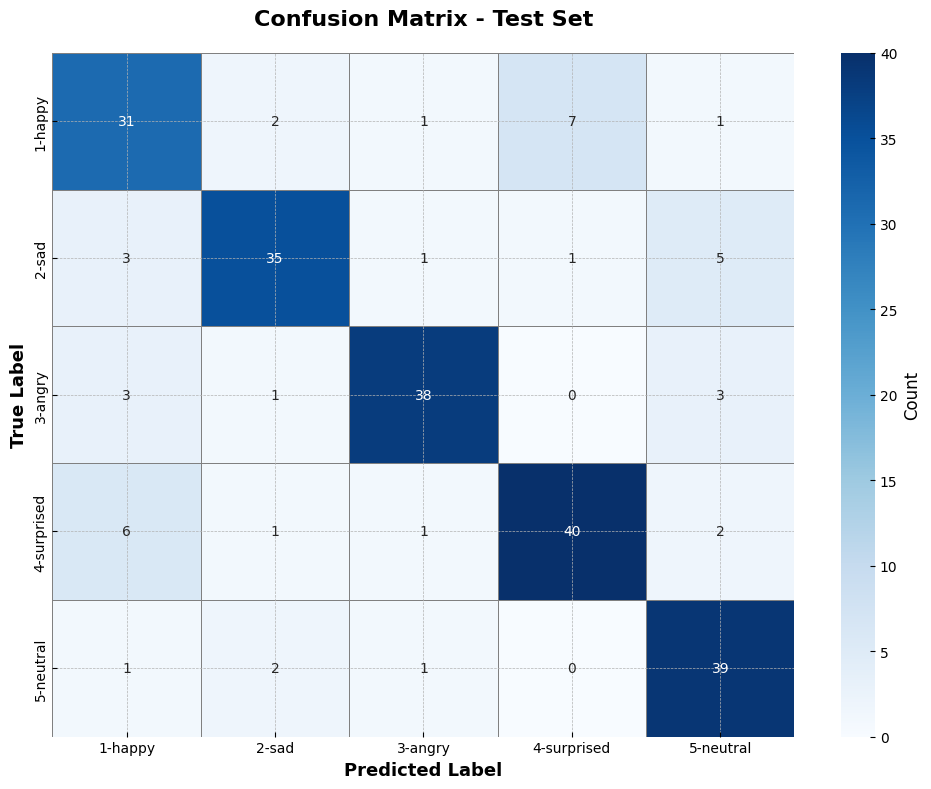

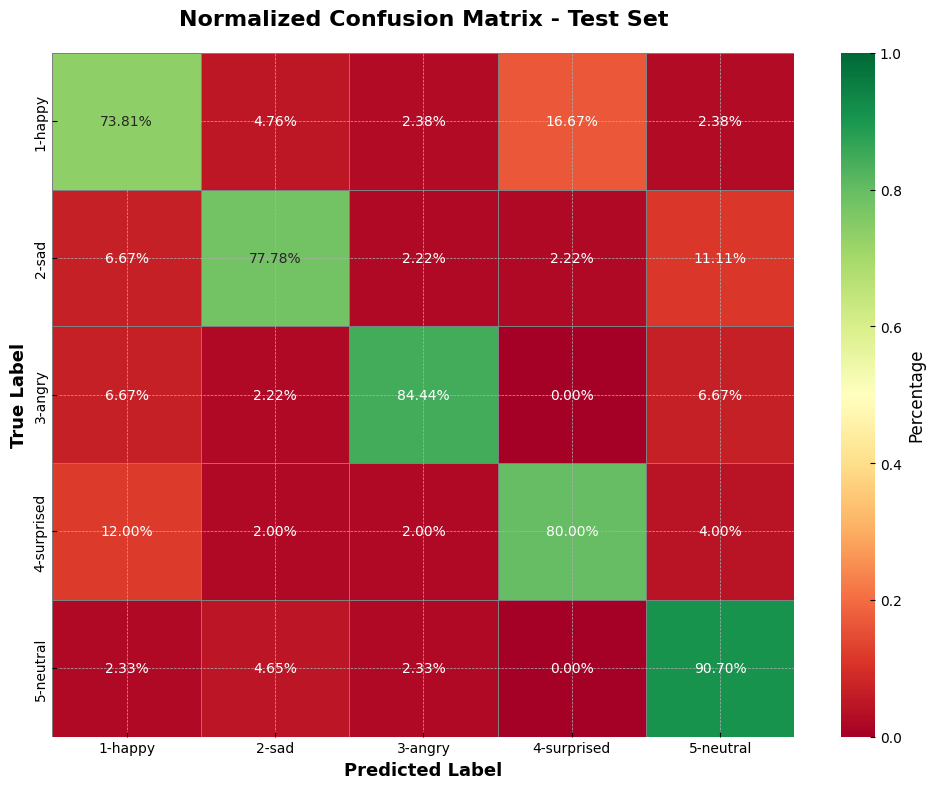

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(test_labels_encoded, test_labels_predictions)

# Emotion names
emotion_names = ['1-happy', '2-sad', '3-angry', '4-surprised', '5-neutral']


plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Count'},
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentage)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2%', 
    cmap='RdYlGn',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Percentage'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0,
    vmax=1
)

plt.title('Normalized Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()